In [1]:
# Standard libraries
import os
import itertools
from collections import Counter
import math

# EEG & Signal Processing
import mne 
from mne.preprocessing import ICA
from mne_connectivity import spectral_connectivity_epochs, envelope_correlation
from mne.time_frequency import stft, psd_array_welch
from scipy.stats import differential_entropy
from scipy.signal import butter, filtfilt
from asrpy import ASR
import braindecode

# Data manip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import scipy.io as sio

# Graph
import networkx as nx

# Torch geometric
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from torch_geometric.utils import dropout_edge
from torch_geometric.nn.norm import BatchNorm
from torch_geometric.nn import global_mean_pool, global_add_pool, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer

# Torch
import torch
import torch.nn.functional as F
import torch.nn as nn

/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Collecting all files with specific ext
def find_files(data_path, ext):
    found_files = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.endswith(ext):
                full_path = os.path.join(root, file)
                found_files.append(full_path)
                
    return found_files

# EEGGraphBuilder Class

In order to setup the "experiment" by testing different functional connectivity measures, edge threshold amounts, and node features, I created a class called EEGGraphBuilder that turns a file path (e.g. a patient's eeg) into graph data objects. I needed a one stop shop that has all these methods to keep everything in one central EEG + Graph data hub.

In [3]:
class EEGGraphBuilder:
    """
    A pipeline for transforming raw EEG signals into graph objects.

    This class handles the end-to-end process of loading EEG data, cleaning, epoching, and extracting node and edge 
    features for Graph Neural Networks (GNN).

    Attributes:
        raw (mne.io.Raw): The underlying MNE Raw object.
        epochs (mne.Epochs): The epoched EEG data after preprocessing.
        sfreq (float): Sampling frequency of the data.
    """
    
    def __init__(
        self,
        file_path,
        clean=False,
        sfreq=None,
        epoch_length=30.0,
        epoch_overlap=15.0,
        fmin=0.5,
        fmax=45,
        edge_threshold=75,
        fc_method='plv',
        node_feature='stft',
        node_drop=None
    ):
        """
        Initializes the builder and loads the EEG data.

        Args:
            file_path (str): Path to the .set (EEGLAB) file.
            clean (bool): If True, applies ASR and ICA cleaning during init.
            sfreq (float, optional): Override for the sampling frequency.
            epoch_length (float): Duration of each epoch in seconds.
            epoch_overlap (float): Overlap between epochs in seconds.
            fmin (float): Minimum frequency for filtering and feature extraction.
            fmax (float): Maximum frequency for filtering and feature extraction.
            edge_threshold (int): Percentile (0-100) used to sparsify the graph edges.
            fc_method (str): Functional connectivity metric ('plv', 'aec', 'corr', etc.).
            node_feature (str): Type of node features ('stft', 'hjorth', 'psd', 'de').
            node_drop (list of str, optional): List of channel names to exclude.
        """
        
        self.file_path = file_path
        self.clean = clean
        self.epoch_length = epoch_length
        self.epoch_overlap = epoch_overlap
        self.fc_method = fc_method
        self.fmin = fmin
        self.fmax = fmax
        self.edge_threshold = edge_threshold
        self.node_feature = node_feature
        self.node_drop = node_drop

        # Placeholders until initialized
        self.raw = None
        self.epochs = None
        self.node_features = None
        self.edge_features = None
        self.edge_index = None


        # Raw file and sampling freq
        raw_load = mne.io.read_raw_eeglab(self.file_path, preload=True)
        
        # Cleaning EEG
        if self.clean is True:
            self.raw = self.clean_eeg(raw_load)
        else:
            self.raw = raw_load
            
        self.sfreq = self.raw.info['sfreq']
        
        # Dropping channels
        if self.node_drop is not None:
            self.raw.drop_channels(self.node_drop)
        
        
    def clean_eeg(self, raw, l_freq=0.5, h_freq=45, asr_sd=17, n_components=None, 
              method='fastica', random_state=99, extreme_thresh=2.0, 
              percent_threshold=10):
        """
        Cleans signal using Artifact Subspace Retrieval (ASR) and Independent Component Analysis (ICA).
        
        Identifies and removes 'extreme' ICA components based on a Z-score threshold 
        of signal activity.
        """

        # Filter and create copy
        raw_for_fit = raw.copy().filter(l_freq=l_freq, h_freq=h_freq, method='fir', verbose=False)

        # Artifact Subspace Retrieval 
        asr_obj = ASR(sfreq=raw.info['sfreq'], cutoff=asr_sd) 
        asr_obj.fit(raw_for_fit)
        raw_for_fit = asr_obj.transform(raw_for_fit)
            
        # ICA fitting
        ica = ICA(n_components=n_components, method=method, random_state=random_state)
        ica.fit(raw_for_fit, verbose=False)

        # Extreme signal activity
        sources = ica.get_sources(raw_for_fit).get_data()  # shape: n_components x n_times
        z_sources = np.abs((sources - sources.mean(axis=1, keepdims=True)) / sources.std(axis=1, keepdims=True))

        # Calculate exceeds threshold
        percent_extreme = np.mean(z_sources > extreme_thresh, axis=1) * 100

        # Identify components where the "extreme" percentage is too high
        reject_components = [i for i, perc in enumerate(percent_extreme) if perc >= percent_threshold]
        ica.exclude = reject_components

        # Create final clean object
        raw_clean = ica.apply(raw_for_fit.copy())

        return raw_clean
        
    def create_epoch(self):
        # shape (n_epochs, n_chan, n_times)
        self.epochs = mne.make_fixed_length_epochs(self.raw, duration=self.epoch_length, overlap=self.epoch_overlap, preload=True) 
        self.n_epochs = len(self.epochs) # store n epochs as attribute to method
        
        return self.epochs
    
    def compute_node_features(self, epoch_idx):
        """
        Extracts features for each electrode (node) for a specific epoch.

        Returns:
            np.ndarray: Matrix of shape (n_channels, n_features).
        """
        if self.node_feature == 'stft':
            return self._compute_node_features_stft(epoch_idx)
        
        elif self.node_feature == 'hjorth':
            return self._compute_node_features_hjorth(epoch_idx)
        
        elif self.node_feature == 'psd':
            return self._compute_node_features_psd(epoch_idx)
        
        elif self.node_feature == 'de':
            return self._compute_node_features_de(epoch_idx)
        
        else:
            print("Pick either: stft, hjorth, psd, or de")
        
    def _compute_node_features_stft(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx] 
        wsize = 256
        tstep = 128
    
        # Compute stft and take the abs (magnitude)
        stft_data = stft(data, wsize=wsize, tstep=tstep)
        stft_mag = np.abs(stft_data) # shape (n_chan, n_filter_freq, n_time_steps)

        # Frequency mask
        freqs = np.fft.rfftfreq(wsize, d=1.0/self.sfreq)
        freq_mask = (freqs >= self.fmin) & (freqs <= self.fmax) # Adjust min/max to focus on certain freq bands
        
        # Average over time
        node_features = stft_mag[:, freq_mask, :].mean(axis=2)
        
        return node_features # (n_chan, n_freq_bins)
    
    def _compute_node_features_hjorth(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]
        
        # 3 Hjorth parameters
        activity = np.var(data, axis=1)
        mobility = np.sqrt(
            np.var(np.diff(data, axis=1), axis=1) / activity
        )
        complexity = (
            np.sqrt(
                np.var(np.diff(np.diff(data, axis=1), axis=1), axis=1)
                / np.var(np.diff(data, axis=1), axis=1)
            ) / mobility
        )

        return np.stack([activity, mobility, complexity], axis=1)
        
    def _compute_node_features_psd(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]        
        psd, freq = psd_array_welch(data, self.sfreq, self.fmin, self.fmax) # Adjust min/max to focus on certain freq bands
        
        return psd # (n_chan, nfreq)
        
    def _bandpass(self, data, low, high, order=4):
        nyq = 0.5 * self.sfreq
        b, a = butter(order, [low/nyq, high/nyq], btype='band')
        return filtfilt(b, a, data)

    def _compute_node_features_de(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]

        # Canonical freq band range
        bands = {
            "delta": (0.5, 4),
            "theta": (4, 8),
            "alpha": (8, 13),
            "beta":  (13, 30),
            "gamma": (30, 45)
        }

        de_features = []

        for low, high in bands.values():
            band_de = []
            for chan in data:
                band_signal = self._bandpass(chan, low, high)
                var = np.var(band_signal)
                de = 0.5 * np.log(2 * np.pi * np.e * var + 1e-8)
                band_de.append(de)
            de_features.append(band_de)

        return np.array(de_features).T # (n_chan, n_bands)
    
    def compute_edge_features(self, epoch_idx):
        # FC measures using spectral_connectivity_epochs method
        mne_fc_methods = ['plv', 'coh', 'pli', 'wpli', 'gc', 'imcoh']

        if self.fc_method.lower() in mne_fc_methods:
            # Slice 1 epoch
            epoch_slice = self.epochs[epoch_idx:epoch_idx + 1]

            conn = spectral_connectivity_epochs(
                epoch_slice,
                method=self.fc_method,
                fmin=self.fmin,
                fmax=self.fmax,
                faverage=True,
                verbose=False
            )

            # Dense FC matrix (n_channels, n_channels)
            fc_matrix = conn.get_data(output="dense")[:, :, 0]

            return self._compute_edge_features_threshold(fc_matrix)
        
        elif self.fc_method == 'aec':
            return self._compute_edge_features_aec(epoch_idx)
        
        elif self.fc_method == 'corr':
            return self._compute_edge_features_corr(epoch_idx)
    
    def compute_edge_brain_region(self, adj_list):
        # Inputs a list of tuple (i,j) relationship
        # Ex. [ (Fp1, Fp2), (O1,O2) ]
        n_chan = len(self.raw.ch_names)
        fc_matrix = np.zeros((n_chan,n_chan))
        
        # Create a mapping dictionary for quick lookup
        ch_map = {name: i for i, name in enumerate(self.raw.ch_names)}
        
        for ch_a, ch_b in adj_list:
            if ch_a in ch_map and ch_b in ch_map:
                i, j = ch_map[ch_a], ch_map[ch_b]
                fc_matrix[i, j] = 1.0
                fc_matrix[j, i] = 1.0
            else:
                print(f"Warning: Channels {ch_a} or {ch_b} not found in data.")
     
        # PyG input
        mask = fc_matrix > 0 
        edge_index = np.array(np.where(mask))
        edge_attr = fc_matrix[mask][:, None]  
        
        return fc_matrix, edge_index, edge_attr
    
    def _compute_edge_features_threshold(self, fc_matrix):
        """
        Applies percentile thresholding to a connectivity matrix.

        Args:
            fc_matrix (np.ndarray): Symmetrical adjacency matrix.

        Returns:
            tuple: (dense_matrix, edge_index, edge_attr) formatted for PyTorch Geometric.
        """
        # Remove self loops
        np.fill_diagonal(fc_matrix, 0)

        # Thresholding
        thresh = np.percentile(fc_matrix, self.edge_threshold)
        mask = fc_matrix >= thresh

        # PyG inputs
        edge_index = np.array(np.where(mask))           
        edge_attr = fc_matrix[mask][:, None]        

        return fc_matrix, edge_index, edge_attr

    def _compute_edge_features_aec(self, epoch_idx):
        epoch_slice = self.epochs[epoch_idx:epoch_idx + 1]

        # Compute envelope corr
        corr_obj = envelope_correlation(epoch_slice, orthogonalize=True, absolute=True)
        fc_matrix = corr_obj.combine().get_data(output='dense')[:, :, 0] # (n_chan, n_chan)
        
        return self._compute_edge_features_threshold(fc_matrix)
        
    def _compute_edge_features_corr(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]
        fc_matrix = np.corrcoef(data)  # shape: (n_channels, n_channels)

        return self._compute_edge_features_threshold(fc_matrix)

# PyG Data class

Pytorch Geometric (PyG) is the main deep learning library I'll be using to build my models and so I need to turn my Numpy matrices (output of the EEGGraphBuilder) into PyG data objects.

In [4]:
class EEGGraphPyG(EEGGraphBuilder):
    """
    A PyTorch Geometric (PyG) class using the EEGGraphBuilder.

    This subclass extends the base builder to convert processed EEG epochs 
    directly into `torch_geometric.data.Data` objects, which are used for 
    training Graph Neural Networks.

    Inherits all preprocessing and feature extraction logic from EEGGraphBuilder.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def pyg_data(self, epoch_idx):
        """
        Generates a PyG Data object for a specific EEG epoch.

        This method computes node feature and functional connectivity, 
        then casts the NumPy arrays into Torch tensors.

        Args:
            epoch_idx (int): The index of the epoch to process.

        Returns:
            torch_geometric.data.Data: A data object containing:
                - x (Tensor): Node feature matrix [n_nodes, n_node_features].
                - edge_index (Tensor): Graph connectivity in COO format [2, n_edges].
                - edge_attr (Tensor): Edge weights/features [n_edges, 1].
                - node_names (list): List of channel names corresponding to nodes.
        """
        node_features = self.compute_node_features(epoch_idx)  # np array (n_nodes, n_node_features)
        x = torch.tensor(node_features, dtype=torch.float)

        # Edge features
        fc_matrix, edge_index, edge_attr = self.compute_edge_features(epoch_idx)
        edge_index = torch.tensor(edge_index, dtype=torch.long)
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        # Naming PyG nodes
        chan_names = self.raw.ch_names
        
        # Return PyG data object
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)        
        data.node_names = chan_names
        
        return data

# Visualize Graphs

I included a class and some code below to visualize the data to (1) make sure my classes above work (2) include the images in my research paper.

In [5]:
class EEGGraphPlot():
    """
    Visualization for EEG functional connectivity graphs.

    Attributes:
        builder (EEGGraphBuilder): An instance of the builder containing 
            the raw EEG info and channel montage.
    """
    def __init__(self, eeg_builder_obj):
        self.builder = eeg_builder_obj
        
    def plot(self, adj_matrix, title='Graph'):
        """
        Visualizes a 2D graph representation of node connectivity.

        This method extracts 3D electrode coordinates from the MNE montage, 
        projects them to 2D, and uses NetworkX to draw nodes and weighted 
        edges based on the input adjacency matrix.

        Args:
            adj_matrix (np.ndarray): A square (n_channels x n_channels) 
                connectivity matrix (e.g., PLV, Correlation).
            title (str, optional): The title for the Matplotlib figure. 
                Defaults to 'Graph'.
        """
        
        node_labels = self.builder.raw.ch_names
        
        # Montage info
        montage = self.builder.raw.get_montage()
        pos_3d = montage.get_positions()['ch_pos']
        pos = {ch: pos_3d[ch][:2] for ch in node_labels} # from 3d to 2d format
        
        # Build Networkx Graph
        G = nx.from_numpy_array(adj_matrix)
        label_mapping = {i: ch for i, ch in enumerate(node_labels)} # Labeling nodes
        G = nx.relabel_nodes(G, label_mapping) 
        
        # Plot Shape
        plt.figure(figsize=(10, 8))
        plt.title(title)
        
        # Draw nodes based on montage position
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
        nx.draw_networkx_labels(G, pos, font_size=8)
        
        # Draw variable edge width based on fc weight
        edges, weights = zip(*nx.get_edge_attributes(G,'weight').items()) 
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=np.array(weights)*1.5)

        plt.show()

## Visualize fixed brain graph

Not setting metadata
52 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 52 events and 15000 original time points ...
0 bad epochs dropped


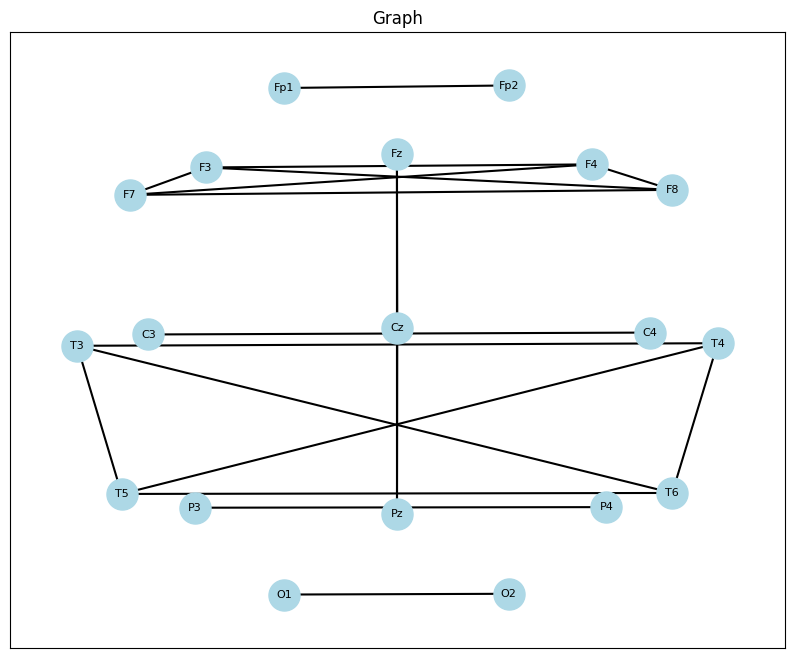

In [6]:
# Load data
file_path = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/openneuro - AD/regular/sub-005_task-eyesclosed_eeg.set'
eeg_obj = EEGGraphBuilder(file_path)
eeg_obj.create_epoch()

# Generate matrix
adj_list = [
            ('Fp1', 'Fp2'), 
            ('O1', 'O2'),   
            ('Fz', 'Cz'), ('Fz', 'Pz'), ('Cz', 'Pz'),
            ('F7', 'F3'), ('F7', 'F4'), ('F7', 'F8'), ('F3', 'F4'), ('F3', 'F8'), ('F4', 'F8'),
            ('C3', 'C4'), 
            ('T3', 'T5'), ('T3', 'T4'), ('T3', 'T6'), ('T4', 'T6'), ('T5', 'T6'), ('T4', 'T5'),
            ('P3', 'P4')
            ]
fc_matrix, _, _ = eeg_obj.compute_edge_brain_region(adj_list)

# Pass the eeg_obj to the plotter
plotter = EEGGraphPlot(eeg_obj)
plotter.plot(fc_matrix)

# FC brain graph w/ drop nodes

Not setting metadata
35 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 35 events and 15000 original time points ...
0 bad epochs dropped


/var/folders/_d/ck_82j6x2vx7b1w6jlm_5cjr0000gn/T/ipykernel_858/25130698.py:65: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_load = mne.io.read_raw_eeglab(self.file_path, preload=True)


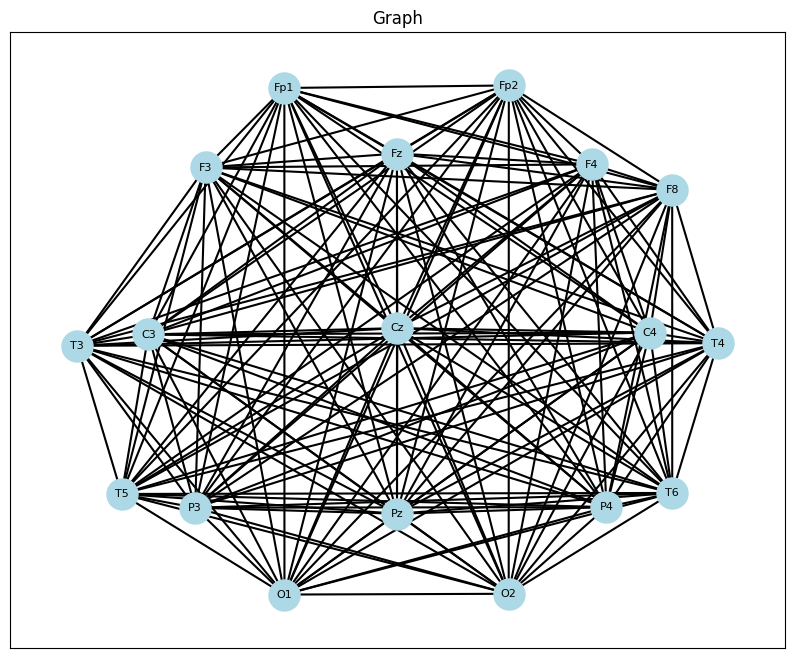

In [7]:
# Load data
file_path = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/openneuro - AD/regular/sub-030_task-eyesclosed_eeg.set'
eeg_obj = EEGGraphBuilder(file_path, fc_method='plv', edge_threshold=99, node_drop=['F7'])
eeg_obj.create_epoch()

# Plot
fc_matrix, _, _ = eeg_obj.compute_edge_features(epoch_idx=0)
plotter = EEGGraphPlot(eeg_obj)
plotter.plot(fc_matrix)

# Patients EEG -> EEGGraphBuilder -> Dataloader

This is the "data engineering" side of the project, if you will. The below functions bridge the gap between raw EEG files and the necessary Dataset & Dataloader for training the Graph Neural Networks. 

In [ ]:
# Create list of PyG data objects 
def eeg_graph_list(eeg_files, patient_tsv, ad_pd='ad', exclude=None,
                epoch_length=30.0, epoch_overlap=15.0, 
                fc_method='plv', node_feature='de', node_drop=None, edge_threshold=90,
                fmin=0.5, fmax=45, 
                save=None
                ):
    """
    Processes a collection of EEG files into a list of PyG data objects.

    This function loops through files, cleans them based on the dataset type 
    (AD vs PD), extracts MMSE/MOCA scores from a TSV file, 
    and slices the continuous EEG into discrete graph-based epochs.

    Args:
        eeg_files (list of str): List of file paths to EEG data files.
        patient_tsv (str): Path to the TSV file containing participant metadata.
        ad_pd (str): Dataset selector. 'ad' for Alzheimer's (MMSE scores) 
            or 'pd' for Parkinson's (MOCA scores).
        exclude (str, optional): filter for group types. 'healthy' excludes 
            control groups based on the dataset logic.
        epoch_length (float): Sliding window size in seconds.
        epoch_overlap (float): Window overlap in seconds.
        fc_method (str): Functional connectivity metric (e.g., 'plv').
        node_feature (str): Node feature type (e.g., 'de' for Differential Entropy).
        edge_threshold (int): Percentile threshold for graph sparsification.
        fmin, fmax (float): Frequency band limits for feature extraction.
        save (str, optional): File path to save the resulting list of objects 
            using torch.save.

    Returns:
        list of torch_geometric.data.Data: A list of all valid epoch-graphs 
            with attached labels (.y), subject IDs, and diagnosis.
            
    Raises:
        AssertionError: If 'save' or 'ad_pd' parameters are missing or invalid.
    """
    assert save, "If parameter is True then include file path as the parameter"
    assert ad_pd, "Parameter must be either ad or pd"
    
    # Loading tsv file
    df = pd.read_csv(patient_tsv, sep='\t')

    # Excluding healthy patients    
    if exclude == 'healthy' and ad_pd == 'ad':
        df = df.query(' Group == "A" or Group == "F" ')
    elif exclude == 'healthy' and ad_pd == 'pd':
        df = df.query(' Group == "PD" ')

    # Loop through all patients
    epoch_graphs = []
    for file in eeg_files:
        # Get sub ID
        file_name = os.path.basename(file)
        sub_id = file_name.split('_')[0]
        
        # Safety check
        row = df.loc[df['participant_id'] == sub_id]
        if row.empty:
            print(f"No score found for {sub_id}")
            continue
        
        # Data.y MMSE or MOCA
        if ad_pd == 'ad':
            data_y = row['MMSE'].iloc[0]      # MMSE 
            sub_label = row['Group'].iloc[0]  # Diagnosis label
        elif ad_pd == 'pd':
            data_y = row['MOCA'].iloc[0]      # MOCA
            sub_label = row['GROUP'].iloc[0]  

        # Cleaning pd dataset
        if ad_pd == 'pd':
            clean=True
        else: 
            clean=False
            
        # Create EEG Object
        eeg_obj = EEGGraphPyG(
                file_path=file,
                clean=clean,
                epoch_length=epoch_length,
                epoch_overlap=epoch_overlap,
                fc_method=fc_method,
                node_feature=node_feature,
                edge_threshold=edge_threshold,
                node_drop=node_drop
            )
        eeg_obj.create_epoch()

        # Turn each epoch into PyG data obj
        for epoch_idx in range(eeg_obj.n_epochs):
            data = eeg_obj.pyg_data(epoch_idx)
            data.y = torch.tensor([data_y], dtype=torch.float32)   # Adding MMSE as data.y label
            data.subject_id = sub_id                               # Adding subject_id attribute
            data.label = sub_label                                 # Adding diagnosis label
            
            epoch_graphs.append(data)
            
    # Saving list of objects for next time
    if save:
        torch.save(epoch_graphs, save)
        print(f"Saved {len(epoch_graphs)} graphs to {save}")
    
    return epoch_graphs


# Takes a list of PyG data objects and splits data to create 3 dataloaders
def subject_loader(graph_list, sub_split='norm', batch_size=16):
    """
    Splits a list of graphs into Train, Validation, and Test PyG DataLoaders.

    Crucially, this function performs a 'Subject-Wise Split' to prevent data 
    leakage, ensuring that all epochs from a single subject stay within the 
    same data split.

    Args:
        graph_list (list): The list of PyG Data objects from `eeg_graph_list`.
        sub_split (str): The splitting strategy:
            - 'norm': Standard random 70/15/15 split of subject IDs.
            - 'strat': Stratified 70/15/15 split, maintaining the ratio 
              of diagnosis groups (labels) across all sets.
        batch_size (int): Number of graphs per batch.

    Returns:
        tuple: (train_loader, val_loader, test_loader) 
            Each is a torch_geometric.loader.DataLoader instance.
    """
    
    # Getting list of all unique subjects
    subjects = list(set(d.subject_id for d in graph_list))

    # How to Split Subjects
    if sub_split == 'norm':
        # ==== 70 / 15 / 15 Random split =====
        train_subs, extra_subs = train_test_split(subjects, test_size=0.3, random_state=42)
        val_subs, test_subs = train_test_split(extra_subs, test_size=0.5, random_state=42)

        # List of epoch graphs for subjects
        train_data = [d for d in graph_list if d.subject_id in train_subs]
        test_data  = [d for d in graph_list if d.subject_id in test_subs]
        val_data  = [d for d in graph_list if d.subject_id in val_subs]
        
    elif sub_split == 'strat':
        # ==== Stratified subject wise splitting =====
        
        # Map every subject to their specific label
        sub_to_label = {d.subject_id: d.label for d in graph_list}
        
        # Dict: {'A': [sub1, sub2], 'C': [sub5, sub6], ...}
        label_to_subs = {}
        for sub_id, label in sub_to_label.items():
            if label not in label_to_subs: # Creates key if not exists
                label_to_subs[label] = []
            label_to_subs[label].append(sub_id)

        all_train_subs, all_val_subs, all_test_subs = [], [], []

        # Loop through each label group and split them individually
        for label, sub_list in label_to_subs.items():            
            # 70/15/15 split per label
            train_subs, extra_subs = train_test_split(sub_list, test_size=0.3, random_state=42)
            val_subs, test_subs = train_test_split(extra_subs, test_size=0.5, random_state=42)

            all_train_subs.extend(train_subs)
            all_val_subs.extend(val_subs)
            all_test_subs.extend(test_subs)

        train_data = [d for d in graph_list if d.subject_id in all_train_subs]
        val_data   = [d for d in graph_list if d.subject_id in all_val_subs]
        test_data  = [d for d in graph_list if d.subject_id in all_test_subs]
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

## Testing Datasets

### Alzheimers

I'm testing out the EEGGraphBuilder, EEG_graph_list, and subject_loader functions to create a .pt file, if one doesn't exist.

In [ ]:
# ===== Testing functions =====
processed_path = 'epoch_graphs_samp_Rnorm_10segment.pt'

if os.path.exists(processed_path):
    print("Loading processed graphs")
    epoch_graphs = torch.load(processed_path, weights_only=False)
    print(f"Loaded {len(epoch_graphs)} graphs.")
    
    train_loader, val_loader, test_loader = subject_loader(epoch_graphs, sub_split='strat', batch_size=16)
    print(f"Dataloader for graphs ready")
    
else:
    # Find files
    file_path = 'dataset/openneuro - AD/regular'
    patient_tsv = 'dataset/openneuro - AD/participants.tsv'
    df = pd.read_csv(patient_tsv, sep='\t')
    all_files = find_files(file_path, '.set')

    epoch_graphs = eeg_graph_list(
        all_files, 
        patient_tsv, 
        ad_pd='ad', exclude='healthy',
        epoch_length=5.0, epoch_overlap=2.5,
        fc_method='plv', node_feature='psd',
        edge_threshold=90, 
        fmin=0.5, fmax=45.0,
        save=processed_path
        )


# ===== Testing correct prints =====
train_loader, val_loader, test_loader = subject_loader(epoch_graphs, 'strat') # load batches
first_batch = next(iter(train_loader)) # Returns a list with len == batch_size

print(first_batch[0]) # First graph
print(f"\nGraph sample data \nSubject ID: {first_batch.subject_id[0]} \nMMSE Score: {first_batch.y[0]} \nLabel: {first_batch.label[0]}")

### Parkinsons 

In [ ]:
# # ===== Testing functions =====
# processed_path = 'pd_epoch_samp.pt'

# if os.path.exists(processed_path):
#     print("Loading processed graphs from local storage...")
#     epoch_graphs = torch.load(processed_path)
#     print(f"Loaded {len(epoch_graphs)} graphs.")
# else:
#     # Find files
#     file_path = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/pd'
#     patient_tsv = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/pd/participants.tsv'
#     df = pd.read_csv(patient_tsv, sep='\t')

#     all_files = find_files(file_path, '.set')
#     # all_files = all_files[0:2]

#     epoch_graphs = eeg_graph_list(all_files, patient_tsv, ad_pd='pd', save=processed_path) # Cleans eeg w/ ad_pd='pd'


# # ===== Testing correct prints =====
# train_loader, val_loader, test_loader = subject_loader(epoch_graphs, 'strat') # load batches
# first_batch = next(iter(train_loader)) # Returns a list with len == batch_size

# print(first_batch[0]) 
# print(f"\nGraph sample data \nSubject ID: {first_batch.subject_id[0]} \nMOCA Score: {first_batch.y[0]} \nLabel: {first_batch.label[0]}")

## GCN

In [ ]:
class GCN(nn.Module):
    def __init__(self, hidden_size, out_chan, edge_drop=0.1, feat_drop=0.2):
        super(GCN, self).__init__()
        self.edge_drop = edge_drop
        self.feat_drop = feat_drop
        
        # 1st layer        
        self.conv1 = GCNConv(-1, hidden_size) # Lazy infer in chan for 1st gcn conv layer
        self.bn1 = BatchNorm(hidden_size)

        # 2nd layer
        self.conv2 = GCNConv(hidden_size, out_chan)
        self.bn2 = BatchNorm(out_chan)   
        
        # MLP
        self.mlp = nn.Sequential(
            nn.Linear(out_chan * 3, 128),
            nn.ReLU(),
            nn.Dropout(feat_drop),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ) # 1 scalar output for MMSE or MOCA score
        
    def forward(self, x, edge_index, batch):
        # Edge dropout (training only)
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=self.edge_drop)

        # 1st layer
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.feat_drop, training=self.training)

        # 2nd layer
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        # x = F.dropout(x, p=self.feat_drop, training=self.training)
        
        # Graph readout 
        avg_x = global_mean_pool(x, batch)
        sum_x = global_add_pool(x, batch)
        max_x = global_max_pool(x, batch)
        
        concat_x = torch.cat((avg_x, sum_x, max_x), dim=1)
        
        # MLP
        out = self.mlp(concat_x)
        # out = 30 * torch.sigmoid(out)

        return out

# Training

This code has min-max scaling on the target labels to shift them between 0-1, and robust scaling on node features.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def robust_scaling(x):
    med_x = x.median()
    x_25 = x.quantile(0.25)
    x_75 = x.quantile(0.75)
    iqr = x_75 - x_25
    
    if iqr.item() < 1e-6:
        iqr = torch.tensor(1.0, device=x.device)

    return (x - med_x) / iqr


# Batch-Level normalization
for data in train_loader.dataset:
    data.x = robust_scaling(data.x)

for data in val_loader.dataset:
    data.x = robust_scaling(data.x)

# Compute global target min-max stats on train_loader
all_train_y = [data.y.view(-1) for data in train_loader.dataset]
all_train_y = torch.cat(all_train_y)

y_min = all_train_y.min().to(device)
y_max = all_train_y.max().to(device)

print(f"Target min: {y_min.item():.4f}")
print(f"Target max: {y_max.item():.4f}")


def train(train_loader, val_loader, y_min, y_max):
    model.train()
    total_loss = 0
    eps = 1e-8 
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index, data.batch).view(-1)
        
        # Min-max normalize target globally
        y_norm = (data.y.view(-1) - y_min) / (y_max - y_min + eps)
        loss = criterion(out, y_norm)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        
    avg_train_loss = total_loss / len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for val_data in val_loader:
            val_data = val_data.to(device)
            
            out = model(val_data.x, val_data.edge_index, val_data.batch).view(-1)
            
            # Min-max normalize validation target globally
            y_norm_val = (val_data.y.view(-1) - y_min) / (y_max - y_min + eps)
            loss = criterion(out, y_norm_val)

            val_loss += loss.item() * val_data.num_graphs
        
        avg_val_loss = val_loss / len(val_loader.dataset)
    
    return avg_train_loss, avg_val_loss
    
    
def evaluate(loader, y_min, y_max):
    model.eval()
    
    total_mae, total_sse, total_mape = 0, 0, 0
    all_pred, all_actual = [], []
    eps = 1e-8
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            
            pred_norm = model(data.x, data.edge_index, data.batch).view(-1)
            actual = data.y.view(-1)

            # Denormalize target predictions using global min-max stats
            pred = pred_norm * (y_max - y_min) + y_min
            errors = pred - actual
            
            total_mae += torch.abs(errors).sum().item()
            total_sse += torch.square(errors).sum().item()        
            
            all_pred.extend(pred.cpu().numpy())
            all_actual.extend(actual.cpu().numpy())
            
            abs_errors = torch.abs(errors)
            mape_batch = (abs_errors / (torch.abs(actual) + eps)).sum().item()
            total_mape += mape_batch
        
        all_pred = np.array(all_pred)
        all_actual = np.array(all_actual)
            
        n = len(loader.dataset)
        mae = total_mae / n
        mape = (total_mape / n) * 100
        mse = total_sse / n
        rmse = math.sqrt(mse)
        
    return mae, mape, rmse, all_pred, all_actual


# Hyperparameters
hidden_size = 128
out_chan = 64
lr = 1e-4
feat_drop = 0.2
edge_drop = 0.1

model = GCN(hidden_size, out_chan, edge_drop, feat_drop).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.SmoothL1Loss(beta=1.0) 

best_val_loss = float('inf')
best_model_state = None
epochs_no_improve = 0
n_epochs = 25
patience = 5

train_loss, val_loss = [], []

# Training loop
for epoch in range(n_epochs):
    current_train_loss, current_val_loss = train(train_loader, val_loader, y_min, y_max)
    train_loss.append(current_train_loss)
    val_loss.append(current_val_loss)
    
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    print(f"Epoch {epoch+1} | Train Loss: {current_train_loss:.4f} | Val Loss: {current_val_loss:.4f}")
    
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

# Evaluate

To help me visualize the model performance I need to view how each MMSE/Diagnosis group performed. I also computed the average difference between the model's prediction and the actual clinical score which helps me determine how to move forward with the project such as eliminating healthy control group from training and testing the model.

In [ ]:
# Plot loss
x = list(range(1, len(train_loss)+1))
plt.plot(x, train_loss, label = 'Training Loss')
plt.plot(x, val_loss, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Printing evaluation
mae, mape, rmse, preds, actuals = evaluate(test_loader, y_min, y_max)
preds_round = np.round(preds)

print(f'MAE: {mae:.4f} | MAPE: {mape:.4f} | RMSE: {rmse:.4f}')

print(f"{'Index':<8} | {'Prediction':<12} | {'Pred Round':<12} | {'Actual':<12} | {'Diff':<12}")
print("-" * 50)
for i, (p, pr, a) in enumerate(zip(preds, preds_round, actuals)):
    diff = p - a
    print(f"{i:<8} | {p:<12.4f} | {pr:<12.4f} | {a:<12.4f} | {diff:<12.4f}")

print("-" * 50)


# Printing unique values
unique_values, counts = np.unique(preds_round, return_counts=True)
col_width = 6 

# Format rows
val_row = "".join(f"{str(int(v)):>{col_width}}" for v in unique_values)
cnt_row = "".join(f"{str(c):>{col_width}}" for c in counts)

print("Unique Values:", val_row)
print("Counts:       ", cnt_row)
print("-" * 50)


# Average diff per MMSE score
mmse_dict = {}
for pred, actual in zip(preds, actuals):
    diff = np.abs(pred - actual)
    
    if actual not in mmse_dict.keys():
        mmse_dict[actual] = []
    mmse_dict[actual].append(diff)

print(f"{'MMSE Score':<12} | {'Avg Abs Diff':<15} | {'Samples':<8}")
print("-" * 50)

for mmse in sorted(mmse_dict.keys()):
    diffs = mmse_dict[mmse]
    avg_diff = np.mean(diffs)
    count = len(diffs)
    
    print(f"{mmse:<12.1f} | {avg_diff:<15.4f} | {count:<8}")

# Explainable Function

Since the MAE was relatively bad at ~2-4 I wanted to see which nodes had the least contribution to the model's prediction and then testing out training and testing the model without those node(s). 

In [ ]:
# def node_explain(model, graph, explanation_type, node_aggr = 'mean', plot=False, print_results=False):
#     """
#     Generates and visualizes XAI explanations for a GNN's EEG predictions.

#     Uses GNNExplainer algorithm to identify the most influential 
#     nodes (electrodes) and edges (connectivity) that contributed to the model's 
#     regression output.

#     Args:
#         model (torch.nn.Module): The trained GNN model to be explained.
#         graph (torch_geometric.data.Data): A single PyG data object (one epoch).
#         explanation_type (str): The type of explanation to generate:
#             - 'model': Focuses on what the model has learned globally.
#             - 'phenomenon': Focuses on why the model made a specific prediction 
#               relative to the target label (requires de-normalization).
#         node_aggr (str): Method to aggregate multi-feature node masks. 
#             Options: 'mean' or 'sum'. Defaults to 'mean'.
#         plot (bool): If True, renders an MNE topomap showing the spatial 
#             distribution of node importance.
#         print_results (bool): If True, prints the top 10 most influential 
#             nodes and edges to the console.

#     Returns:
#         dict: A dictionary containing ranked results:
#             - 'top_nodes': List of channel names ordered by importance.
#             - 'top_nodes_idx': Tensor of node indices ordered by importance.
#             - 'top_edges': List of node-name tuples (e.g., ('Fp1', 'Fp2')) 
#               ordered by importance.
#             - 'top_edges_idx': Tensor of edge indices ordered by importance.
#     """
#     data = graph.to(device)
#     node_names = data.node_names
#     batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)
    
#     if explanation_type == 'model':
#         explainer = Explainer(
#         model=model,
#         algorithm=GNNExplainer(epochs=200),
#         explanation_type='model',       
#         node_mask_type='attributes',
#         edge_mask_type='object',
#         model_config=dict(
#             mode='regression',          
#             task_level='graph',      
#             return_type='raw'
#             )
#         )
#         explanation = explainer(
#             x=data.x,
#             edge_index=data.edge_index,
#             batch=batch
#         )
#     else:
#         explainer = Explainer(
#         model=model,
#         algorithm=GNNExplainer(epochs=200),
#         explanation_type='phenomenon',      
#         node_mask_type='attributes',
#         edge_mask_type='object',
#         model_config=dict(
#             mode='regression',          
#             task_level='graph',      
#             return_type='raw'
#             )
#         )

#         # De-Normalize
#         pred_norm = model(data.x, data.edge_index, batch)
#         pred = pred_norm * y_std + y_mean
#         y_norm = (data.y - y_mean) / y_std

#         # Generate explanation
#         explanation = explainer(
#             x=data.x,
#             edge_index=data.edge_index,
#             batch=batch,
#             target=y_norm.view(-1)
#         )
    
#     # Ranking node importance
#     if node_aggr == 'mean':
#         node_importance = explanation.node_mask.mean(dim=1)
#     elif node_aggr == 'sum':
#         node_importance = explanation.node_mask.sum(dim=1)
        
#     top_nodes_idx = torch.argsort(node_importance, descending=True)
    
#     top_nodes = []
#     for idx in top_nodes_idx:
#         top_nodes.append(node_names[idx.item()])
    
    
#     # Ranking edge importance
#     edge_importance = explanation.edge_mask
#     top_edges_idx = torch.argsort(edge_importance, descending=True)
    
#     top_edges = [] # list of tuples
#     for idx in top_edges_idx:
#         n1 = data.edge_index[0, idx].item()
#         n2 = data.edge_index[1, idx].item()
#         edge_tuple = (node_names[n1], node_names[n2])
#         top_edges.append(edge_tuple)
    
    
#     xgnn_dict = {
#         'top_nodes': top_nodes,
#         'top_nodes_idx': top_nodes_idx,
#         'top_edges': top_edges,
#         'top_edges_idx': top_edges_idx
#     }
    
    
#     # Print results
#     if print_results:
#         print("\nTop Nodes:")
#         for i in range(10):
#             print(f"{i+1}. {top_nodes[i]} (idx={top_nodes_idx[i].item()})")

#         print("\nTop Edges:")
#         for i in range(10):
#             print(f"{i+1}. {top_edges[i]} (idx={top_edges_idx[i].item()})")


#     # Visualize plot
#     if plot:
#         info = mne.create_info(ch_names=node_names, sfreq=500, ch_types='eeg')
#         info.set_montage('standard_1020')

#         fig, ax = plt.subplots(figsize=(7, 7))
#         im, _ = mne.viz.plot_topomap(node_importance.cpu().numpy(), info, axes=ax, show=False)

#         plt.colorbar(im, ax=ax, label="Importance Score")
#         plt.title("Spatial Distribution of Node Importance")
#         plt.show()
        
#     return xgnn_dict

# # Test run
# batch = next(iter(test_loader))
# graph = batch.to_data_list()[0]
# results = node_explain(model, graph, 'model', plot=True, print_results=True)

# Explain Healthy Patients

The code below is the for loop to apply my node_explain function across train, val and testing datasets. 

In [ ]:
# combined_loaders = itertools.chain(train_loader, val_loader, test_loader)

# top_n_track = 5
# model_node_counter = Counter()
# phenom_node_counter = Counter()

# healthy_patient_count = 0

# for i, batch in enumerate(combined_loaders):
    
#     # Batch to list of individual graph obj
#     graph_list = batch.to_data_list()
    
#     for graph in graph_list:
#         # Filtering healthy patients
#         if graph.y.item() == 30.0:
#             healthy_patient_count += 1
            
#             # --- MODEL EXPLANATION ---
#             model_results = node_explain(
#                 model, graph, explanation_type='model', 
#                 plot=False, print_results=False
#             )
#             top_model_nodes = model_results['top_nodes'][:top_n_track] # Getting only top n nodes
#             model_node_counter.update(top_model_nodes)
            
#             # --- PHENOMENON EXPLANATION ---
#             phenom_results = node_explain(
#                 model, graph, explanation_type='phenomenon', 
#                 plot=False, print_results=False
#             )
#             top_phenom_nodes = phenom_results['top_nodes'][:top_n_track]
#             phenom_node_counter.update(top_phenom_nodes)


# # Print table results
# print("-" * 50)
# print(f"TOP ELECTRODES: MODEL EXPLANATION")
# print(f"(What the model actually relied on)")
# print("-" * 50)
# for node, count in model_node_counter.most_common(10):
#     freq = (count / healthy_patient_count) * 100
#     print(f"{node:<5} | Appeared in Top {top_n_track} for {count:<3} patients ({freq:.1f}%)")

# print("\n" + "-" * 50)
# print(f"TOP ELECTRODES: PHENOMENON EXPLANATION")
# print(f"(The true biomarkers for an MMSE of 30)")
# print("-" * 50)
# for node, count in phenom_node_counter.most_common(10):
#     freq = (count / healthy_patient_count) * 100
#     print(f"{node:<5} | Appeared in Top {top_n_track} for {count:<3} patients ({freq:.1f}%)")